In [1]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')

from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
#from ftnmt_loss import ftnmt_loss
from datasets import *

from sklearn.metrics import matthews_corrcoef

import random

import rasterio
from rasterio.enums import ColorInterp
from scipy import ndimage

import matplotlib.pyplot as plt
%matplotlib inline

import higra as hg
import torch
import pickle

In [2]:
df = pd.read_csv('training_data/8m-resolution/US_points_final_8m.csv')
train_df = df[df['data_split']=='train'].sample(frac=1)
val_df = df[df['data_split']=='val'].sample(frac=1)
test_df = df[df['data_split']=='test'].sample(frac=1)

train_names = train_df['image_filename'].tolist()
val_names = val_df['image_filename'].tolist()
test_names = test_df['image_filename'].tolist()
train_names_label = train_df['mask_filename'].tolist()
val_names_label = val_df['mask_filename'].tolist()
test_names_label = test_df['mask_filename'].tolist()

In [3]:
n_filters = 32
depth = 6
n_classes = 1

ctx = mx.gpu(0)
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


[16:10:55] /work/mxnet/src/base.cc:79: cuDNN lib mismatch: linked-against version 8200 != compiled-against version 8500.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [4]:
import imageio.v2 as imageio
import cv2

def compute_field_boundaries_and_extent(segmentation):
    unique_labels = np.unique(segmentation)
    unique_labels = np.delete(unique_labels, np.where(unique_labels == 0))
    boundaries = np.zeros_like(segmentation)
    extent = np.zeros_like(segmentation)
    field_original_with_border = np.ones((segmentation.shape[0]+2, segmentation.shape[1]+2))
    for label in unique_labels:
        field_original = (segmentation==label).astype(int)
        field_original_with_border[1:-1, 1:-1] = field_original
        field_extent = ndimage.binary_erosion(field_original_with_border).astype(int)[1:-1, 1:-1]
        field_boundaries = field_original - field_extent
        extent += field_extent
        boundaries += field_boundaries
    return boundaries, extent

class NAIP_Data_For_Conformal(gluon.data.Dataset):
    
    def __init__(self, fold, image_names=None, label_names=None):
        
        self.fold = fold
        self.image_names = image_names
        self.label_names = label_names
        
    def __getitem__(self, item):
        
        # take random crop of image
        image_path = self.image_names[item]
        image = imageio.imread(image_path)
        nrow, ncol, nchannels = image.shape
        segmentation_path = self.label_names[item]
        segmentation = imageio.imread(segmentation_path)
        crop_size = 256
        
        topleft_x = np.random.choice(np.arange(0, nrow-crop_size+1))
        topleft_y = np.random.choice(np.arange(0, ncol-crop_size+1))
        image = image[topleft_x:topleft_x+crop_size, topleft_y:topleft_y+crop_size]
        segmentation = segmentation[topleft_x:topleft_x+crop_size, topleft_y:topleft_y+crop_size]
        
        if self.fold == 'train':
            # brightness augmentation
            image = np.minimum(np.random.uniform(low=0.8, high=1.25) * image, 255).astype(np.uint8)

            # rotation augmentation
            k = np.random.randint(low=0, high=4)
            image = np.rot90(image, k, axes=(0,1))
            segmentation = np.rot90(segmentation, k, axes=(0,1))

            # flip augmentation
            if np.random.uniform() > 0.5:
                image = np.flip(image, axis=0)
                segmentation = np.flip(segmentation, axis=0)
            if np.random.uniform() > 0.5:
                image = np.flip(image, axis=1)
                segmentation = np.flip(segmentation, axis=1)
        
        boundary_mask, extent_mask = compute_field_boundaries_and_extent(segmentation)
        distance_mask = get_distance(extent_mask)
        
        # define label mask
        label_mask = np.array((extent_mask + boundary_mask) >= 1, dtype=np.float32)
        
        image = mx.nd.array(np.moveaxis(image, -1, 0))
        
        extent_mask = mx.nd.array(np.expand_dims(extent_mask, 0))
        boundary_mask = mx.nd.array(np.expand_dims(boundary_mask, 0))
        distance_mask = mx.nd.array(np.expand_dims(distance_mask, 0))
        label_mask = mx.nd.array(np.expand_dims(label_mask, 0))

        return image, segmentation
    
    def __len__(self):
        return len(self.image_names)

In [5]:
# https://github.com/waldnerf/decode/blob/main/postprocessing/instance_segmentation.py
def watershed(input_hws, t_bound):
    # Create the directed graph
    size = input_hws.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        input_hws,
        hg.WeightFunction.mean)

    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)
    
    # Get individual fields
    # by cutting the graph using altitude
    instances = hg.labelisation_horizontal_cut_from_threshold(
        tree,
        altitudes,
        threshold=t_bound).astype(float)
    return instances

# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

# Conformal calibration

In [13]:
np.random.seed(0)

val_dataset = NAIP_Data_For_Conformal(
    fold='val', 
    image_names=val_names, 
    label_names=val_names_label)
val_dataloader = gluon.data.DataLoader(val_dataset, batch_size=1)

T_values = np.concatenate([[0], np.arange(0.001, 0.01, 0.001), np.arange(.01, 1.01, .01)])

image_size = 256
points_per_image = 20
results = {"image_filename": [], "mask_filename":[], "coord": [], "IOUs": []}
for batch_i, (img, segmentation) in tqdm(enumerate((val_dataloader))):
    if batch_i >= 200:
        break

    xs = np.random.randint(image_size, size=points_per_image)
    ys = np.random.randint(image_size, size=points_per_image)

    img = img.as_in_context(ctx)
    segmentation = segmentation[0].asnumpy()

    logits, bound, dist = model(img)
    logits = logits[0][0].asnumpy()
    bound = bound[0][0].asnumpy()
    dist = dist[0][0].asnumpy()

    coords = []
    for x, y in zip(xs, ys):
        if segmentation[x, y] != 0:
            coord = (x, y)
            coords.append(coord)
            '''
            true_field = segmentation==segmentation[coord]
            true_field_indices = np.argwhere(true_field)
            # check if true field touches edge of image
            if (0 not in true_field_indices.flatten()) and (image_size-1 not in true_field_indices.flatten()):
                coords.append(coord)
            '''
    
    IOUs = []
    if len(coords) != 0:
        for T in T_values:
            pred_segmentation = watershed(bound, T)
            IOUs_T = []
            for coord in coords:
                true_field = segmentation==segmentation[coord]
                pred_field = pred_segmentation==pred_segmentation[coord]
                IOU = iou(torch.from_numpy(true_field), torch.from_numpy(pred_field)).numpy().item()
                IOUs_T.append(IOU)
            IOUs.append(IOUs_T)

    # store results
    results["image_filename"].extend(np.repeat(val_dataset.image_names[batch_i], len(coords)))
    results["mask_filename"].extend(np.repeat(val_dataset.label_names[batch_i], len(coords)))
    results["coord"].extend(coords)
    results["IOUs"].extend(np.array(IOUs).T.tolist())

200it [16:54,  5.07s/it]


In [14]:
results_table = pd.DataFrame.from_dict(results)
results_table

,image_filename,mask_filename,coord,IOUs
0,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(87, 208)","[0.8285714387893677, 0.8285714387893677, 0.828..."
1,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(183, 65)","[0.01372712105512619, 0.03410981595516205, 0.0..."
2,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(203, 117)","[0.03505317121744156, 0.8742212057113647, 0.88..."
3,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(68, 85)","[0.056355930864810944, 0.8679364919662476, 0.8..."
4,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(47, 69)","[0.027330508455634117, 0.8679364919662476, 0.8..."
...,...,...,...,...
879,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(247, 32)","[0.002346536610275507, 0.0651031881570816, 0.2..."
880,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(234, 85)","[0.004786934703588486, 0.0932982936501503, 0.2..."
881,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(242, 117)","[0.00647644093260169, 0.09068742394447327, 0.1..."
882,training_data/8m-resolution/US_NAIP_Semios/ima...,training_data/8m-resolution/US_NAIP_Semios/mas...,"(193, 81)","[0.004411488771438599, 0.004411488771438599, 0..."


In [15]:
file = open('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/conformal_ious_validation_200.pkl', 'wb')
pickle.dump(results_table, file)
file.close()

In [20]:
file = open('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/conformal_ious_validation_200.pkl', 'rb')
results_table = pickle.load(file)
file.close()

In [21]:
IOU_threshold = 0.7
def compute_Ts_with_high_IOU(IOUs):
    indices_with_high_IOU = np.argwhere(np.array(IOUs) >= IOU_threshold)[:, 0]
    return T_values[indices_with_high_IOU]

results_table["max IOU"] = results_table["IOUs"].map(lambda x: np.max(x))
results_table["Ts with high IOU"] = results_table["IOUs"].map(compute_Ts_with_high_IOU)

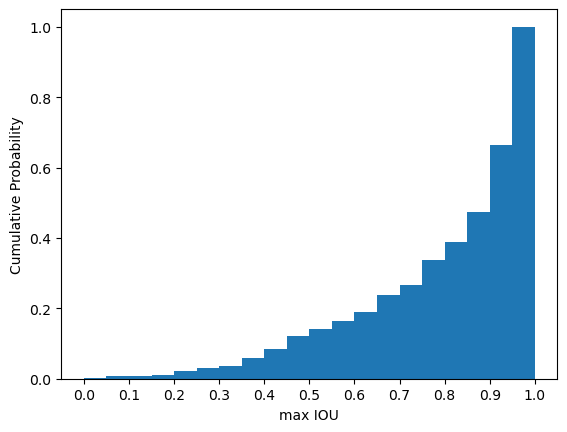

In [22]:
plt.hist(results_table["max IOU"], bins=np.arange(0, 1.01, .05), density=True, cumulative=True)
plt.xlabel("max IOU")
plt.ylabel("Cumulative Probability")
plt.xticks(np.arange(0, 1.01, 0.1))
plt.show()

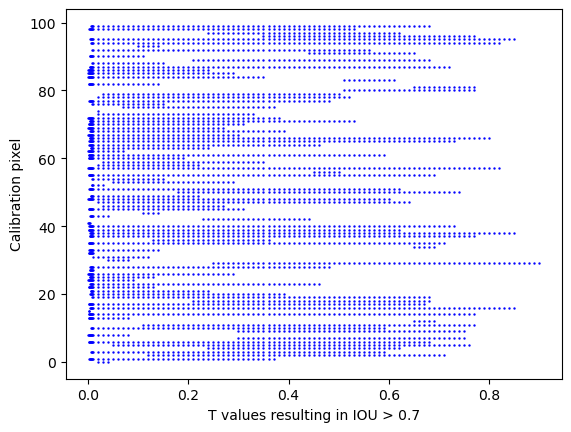

In [23]:
np.random.seed(0)

results_table_high_IOUs = results_table[results_table["max IOU"] > IOU_threshold]
results_table_high_IOUs = results_table_high_IOUs.sample(n=100)
Ts_with_high_IOU = np.array(results_table_high_IOUs["Ts with high IOU"])

for i in range(len(Ts_with_high_IOU)):
    xs = Ts_with_high_IOU[i]
    ys = np.repeat(i, len(xs))
    plt.scatter(xs, ys, color='blue', s=0.5)
    plt.xlabel(f"T values resulting in IOU > {IOU_threshold}")
    plt.ylabel("Calibration pixel")

In [26]:
len(np.unique(results_table["image_filename"]))

176